<a href="https://colab.research.google.com/github/alicienty/HW2/blob/main/Lukyanchikova_log_reg_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание: линейные модели для NLP**

## **Что будем делать?**
Мы будем предсказывать, к какой категории относится новость: про хоккей или про космос.

## **Часть 1. Практическая работа (8 баллов)**

### **1. Загрузка данных**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups

# Загружаем данные о новостях
categories = ['rec.sport.hockey', 'sci.space']
newsgroups = fetch_20newsgroups(subset='all',
                               categories=categories,
                               shuffle=True,
                               random_state=42)

# Создаём таблицу с данными
data = pd.DataFrame({
    'text': newsgroups.data,
    'category': newsgroups.target  # 0 = хоккей, 1 = космос
})

print("Размер данных:", data.shape)
print("\nПервые 3 текста:")
for i in range(3):
    print(f"Текст {i+1}: {data['text'][i][:200]}...")

Размер данных: (1986, 2)

Первые 3 текста:
Текст 1: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I.D.: mksol.1993Apr22.204742.10671
Organization: Texas Instruments Inc
Lines: 62

In <C5tvL2.1In@herme...
Текст 2: From: epritcha@s.psych.uiuc.edu ( Evan Pritchard)
Subject: Re: div. and conf. names
Distribution: na
Organization: UIUC Department of Psychology
Lines: 59

maynard@ramsey.cs.laurentian.ca (Roger Mayna...
Текст 3: From: baalke@kelvin.jpl.nasa.gov (Ron Baalke)
Subject: Galileo Update - 04/29/93
Keywords: Galileo, JPL
Organization: Jet Propulsion Laboratory
Lines: 134
NNTP-Posting-Host: kelvin.jpl.nasa.gov
News-S...


**Задание 1:**
- Сколько всего текстов в датасете?
- Выведите количество текстов в каждой категории

In [3]:
type(data)

pandas.core.frame.DataFrame

In [4]:
data.head()

,text,category
0,From: mccall@mksol.dseg.ti.com (fred j mccall ...,1
1,From: epritcha@s.psych.uiuc.edu ( Evan Pritcha...,0
2,From: baalke@kelvin.jpl.nasa.gov (Ron Baalke)\...,1
3,From: mse@cc.bellcore.com (25836-michael evenc...,0
4,From: apanjabi@guvax.acc.georgetown.edu\nSubje...,0


Считаем количество текстов, проверим, все ли ячейки заполнены

In [6]:
data['text'].isnull().sum() #пропусков нет

np.int64(0)

In [10]:
print(f"Всего в датасете {len(data['text'])} текстов")

Всего в датасете 1986 текстов


Считаем количество текстов каждой категории

In [15]:
data['category'].value_counts()

,count
category,
0,999
1,987


In [18]:
f"В категории хоккей {data['category'].value_counts()[0]} текстов"

'В категории хоккей 999 текстов'

In [20]:
f"В категории космос {data['category'].value_counts()[1]} текстов"

'В категории космос 987 текстов'

### **2. Анализ данных**

In [22]:
# Ваш код здесь
# Подсказка: используйте value_counts()
hockey = int(data['category'].value_counts()[0])
space = int(data['category'].value_counts()[1])

if hockey > space:
  print('В категории хоккей больше текстов')
else:
  print('В категории космос больше текстов')

В категории хоккей больше текстов


**Вопрос:** Какая категория больше: хоккей или космос?

### **3. Очистка текста**

In [24]:
import re

def clean_text(text):
    # Ваш код здесь

    # 1. Привести текст к нижнему регистру (.lower())
    text = text.lower()

    # 2. Удалить всё, кроме букв и пробелов (re.sub)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 3. Убрать лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Применяем функцию
data['clean_text'] = data['text'].apply(clean_text)

# Проверяем
print("До очистки:", data['text'][0][:100])
print("После очистки:", data['clean_text'][0][:100])

До очистки: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I.
После очистки: from mccall mksol dseg ti com fred j mccall subject re vandalizing the sky article i d mksol apr org


### **4. Создание признаков (векторизация)**

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

# Ваш код здесь

# 1. Создайте CountVectorizer (остановитесь на английском)
vectorizer = CountVectorizer(stop_words='english')

# 2. Преобразуйте тексты в числа (fit_transform)
corpus = data['clean_text']
X = vectorizer.fit_transform(corpus)

# 3. Выведите сколько слов получилось
print("Количество слов:", len(vectorizer.get_feature_names_out()))

Количество слов: 24480


In [27]:
type(vectorizer.get_feature_names_out())

numpy.ndarray

In [30]:
vectorizer.get_feature_names_out()[56]

'absent'

**Вопрос:** Сколько уникальных слов нашёл CountVectorizer?

vectorizer.get_feature_names_out() — словарь, а значит, уже отражает количество только уникальных объектов. CountVectorizer нашел 24480 уникальных слов

### **5. Разделение данных**

In [32]:
from sklearn.model_selection import train_test_split

# Цель: предсказать категорию (0 или 1)
X = X # что сюда подставить? (признаки) — ставим матрицу

y = data['category'] # что сюда подставить? (целевая переменная) — категории, к которым относим объекты

# Ваш код здесь
# Разделите данные на 80% обучение, 20% тест
# Используйте random_state=42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **6. Обучение модели**

In [33]:
from sklearn.linear_model import LogisticRegression

# Ваш код здесь
# 1. Создайте модель логистической регрессии
model = LogisticRegression()

# 2. Обучите её на обучающих данных
model.fit(X_train, y_train)

# 3. Сделайте предсказания для тестовых данных
y_pred = model.predict(X_test)

### **7. Оценка модели**

In [37]:
from sklearn.metrics import accuracy_score

# Ваш код здесь
# 1. Вычислите accuracy (точность) модели
accuracy = accuracy_score(y_test, y_pred)
# 2. Выведите результат в процентах
f'Точность модели достигает {accuracy*100}%'

'Точность модели достигает 99.2462311557789%'

**Вопрос:** Какая точность у вашей модели? Что это значит?

У модели очень высокая точность — 99% текстов она классифицирует правильно

### **8. Анализ ошибок**

In [45]:
from sklearn.metrics import confusion_matrix

# Ваш код здесь
# 1. Создайте матрицу ошибок
cm = confusion_matrix(y_test, y_pred)
# 2. Выведите её
print(cm)

[[201   1]
 [  2 194]]


In [ ]:
# БОНУС: визуализируйте матрицу ошибок
plt.figure(figsize=(6, 4))
# Ваш код для визуализации здесь
plt.show()

In [52]:
import seaborn as sns

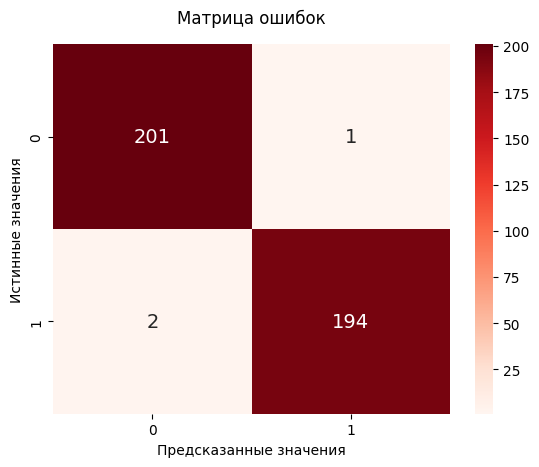

In [56]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', annot_kws={'fontsize': 14})
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок', pad=15)
plt.show()

**Вопрос:** Сколько текстов про космос модель приняла за хоккей?

In [58]:
print(f'Модель приняла за тексты про космос {cm[0][1]} текст про хоккей')

Модель приняла за тексты про космос 1 текст про хоккей


In [59]:
print(f'Модель приняла за тексты про хоккей {cm[1][0]} текста про космос')

Модель приняла за тексты про хоккей 2 текста про космос
